# StreamFlix Customer Churn Prediction Analysis

In [1]:
## Importing all required Libraries

# BASIC LIBRARIES (DATA HANDLING)

import pandas as pd
import numpy as np

# DATA VISUALIZATION (EDA)

import matplotlib.pyplot as plt
import seaborn as sns

# DATA PREPROCESSING

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# TRAIN TEST SPLIT

from sklearn.model_selection import train_test_split

# CLASS IMBALANCE HANDLING

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# MACHINE LEARNING MODELS

#!pip install xgboost
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# MODEL EVALUATION METRICS

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

# CROSS VALIDATION

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate

# HYPERPARAMETER TUNING

from sklearn.model_selection import GridSearchCV


In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/msaricaumbc/DS_data/master/ds602/2026/streaming_churn.csv')
df.shape

(10000, 38)

In [3]:
df.head().T

,0,1,2,3,4
subscription_start_date,2023-03-13,2020-02-15,2021-05-17,2021-02-11,2023-09-06
subscription_length_days,659,1781,1324,1419,482
subscription_plan,standard,student,premium,premium,basic
monthly_price,15.99,7.99,19.99,19.99,9.99
billing_cycle,monthly,monthly,monthly,monthly,monthly
payment_method,paypal,credit_card,credit_card,paypal,debit_card
total_watch_time_hours,5.17082,173.005893,177.950326,29.313555,8.381127
sessions_count,3.015887,87.408494,109.0,6.723148,4.719065
avg_session_duration_minutes,103.9745,116.887515,93.389997,187.994139,100.288519
days_since_last_watch,4.971187,2.61486,1.919463,3.537331,8.166934


# Exploratory Data Analysis

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 38 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   subscription_start_date       10000 non-null  object 
 1   subscription_length_days      10000 non-null  int64  
 2   subscription_plan             10000 non-null  object 
 3   monthly_price                 10000 non-null  float64
 4   billing_cycle                 10000 non-null  object 
 5   payment_method                10000 non-null  object 
 6   total_watch_time_hours        10000 non-null  float64
 7   sessions_count                10000 non-null  float64
 8   avg_session_duration_minutes  10000 non-null  float64
 9   days_since_last_watch         10000 non-null  float64
 10  unique_titles_watched         10000 non-null  float64
 11  content_completion_rate       10000 non-null  float64
 12  abandoned_series_count        10000 non-null  int64  
 13  bi

# Checking for Null Values

In [5]:
df.isnull().sum().sort_values(ascending=False)

support_ticket_reasons          7534
devices_used                     500
genres_watched                   500
ratings_given_count              500
reviews_written_count            500
subscription_start_date            0
support_tickets_count              0
has_profile                        0
number_of_profiles                 0
watchlist_size                     0
downloads_count                    0
account_on_hold                    0
payment_failures_count             0
subscription_length_days           0
used_free_trial                    0
subscription_length_months         0
current_month                      0
days_until_next_billing            0
primary_os                         0
devices_used_count                 0
primary_device                     0
new_content_ratio                  0
subscription_plan                  0
monthly_price                      0
billing_cycle                      0
payment_method                     0
total_watch_time_hours             0
s

As we can see, the dataset contains some missing values. 
So eventually we will replace the **numerical missing values with median**
and the **categorical missing values with the mode** (most frequent value).

# Checking Class Balance

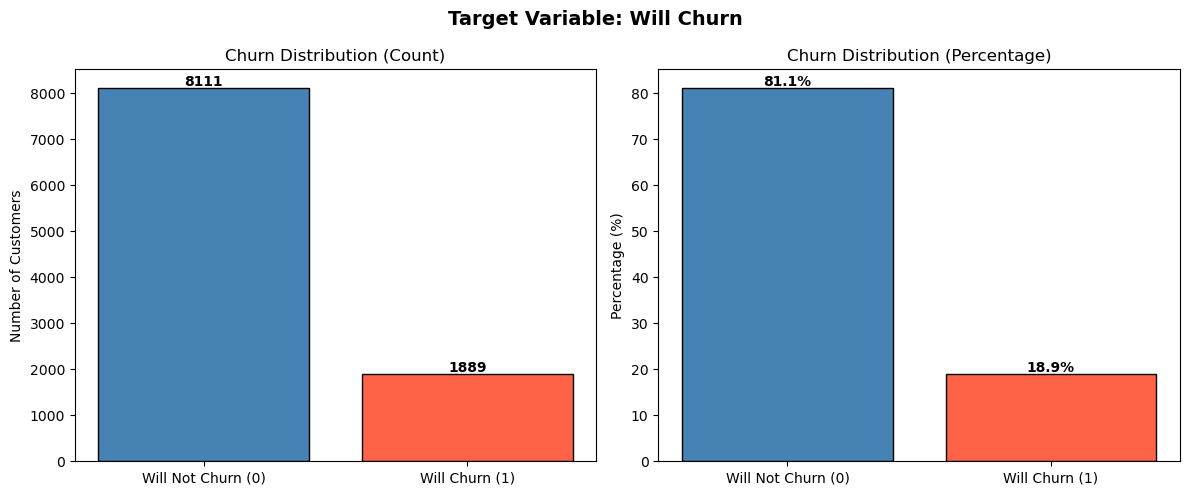

In [6]:
# --- Visualization 1: Churn Distribution ---

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
churn_counts = df['will_churn'].value_counts()
axes[0].bar(['Will Not Churn (0)', 'Will Churn (1)'], churn_counts.values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Churn Distribution (Count)')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Percentage plot
churn_pct = df['will_churn'].value_counts(normalize=True) * 100
axes[1].bar(['Will Not Churn (0)', 'Will Churn (1)'], churn_pct.values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[1].set_title('Churn Distribution (Percentage)')
axes[1].set_ylabel('Percentage (%)')
for i, v in enumerate(churn_pct.values):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold')

plt.suptitle('Target Variable: Will Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz1_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

The dataset is highly imbalanced.
We will eventually handle this using Synthetic Minority Oversampling Technique (SMOTE)

# Feature Engineering

In [7]:
# 1. New customer or not = new if subscription length < 60

df["is_new_customer"] = (df["subscription_length_days"] < 60).astype(int)

Flags customers with < 60 days tenure; newer customers are more likely to churn before forming a habit.

In [8]:
# 2. Watch time per session = total watchtime / no. of sessions

df["watch_time_per_session"] = df["total_watch_time_hours"] / (df["sessions_count"] + 1) #1 added to denominator to avoid dividing by 0

Measures how long a customer watches per visit; low values may indicate disengagement.

In [9]:
# 3. Engagement score = sessions count + unique titles watched + watchlist size + number of ratings given

df["engagement_score"] = (
    df["sessions_count"] +
    df["unique_titles_watched"] +
    df["watchlist_size"] +
    df["ratings_given_count"]
)

Composite score of sessions, titles watched, watchlist size, and ratings; higher scores signal stronger platform attachment.

In [10]:
# 4. Content Diversity = no. of genres watched / no. of unique titles watched

df["content_diversity"] = df["genres_watched_count"] / (df["unique_titles_watched"] + 1)

Ratio of genres explored to titles watched; diverse viewers tend to find more value in the platform.

In [11]:
# 5. Payment risk score = payment failure count + account on hold count

df["payment_risk_score"] = df["payment_failures_count"] + df["account_on_hold"]

Combines payment failures and account holds; financial friction is a strong churn predictor.

In [12]:
# 6. Inactive user = days since last watched > 7

df["inactive_user_flag"] = np.where(df["days_since_last_watch"] > 7, 1, 0)

Flags users who haven't watched in over 7 days; inactivity is one of the clearest early churn signals.

In [13]:
# 7. Support issue flag = support ticket count > 0

df["support_issue_flag"] = np.where(df["support_tickets_count"] > 0, 1, 0)

Marks customers who raised support tickets; unresolved issues often lead to cancellation.

In [14]:
# 8. Price per day

df['price_per_day'] = df['monthly_price'] / 30

Normalizes monthly price to a daily cost; helps capture perceived value relative to usage.

In [15]:
# 9. Binge watcher flag

df['binge_watcher_flag'] = (df['binge_sessions_count'] > 0).astype(int)

Identifies customers with binge sessions; binge watchers are deeply engaged and less likely to leave.

In [16]:
# 10. High engagement user — customers above median engagement
median_engagement = df['engagement_score'].median()

df['high_engagement_user'] = (df['engagement_score'] > median_engagement).astype(int)

Binary flag for customers with above-median engagement; cleanly separates highly active from passive users.

In [17]:
# 11. Tenure bucket — groups customers into loyalty tiers
def assign_tenure_bucket(days):
    if days < 90:
        return 'New'
    elif days < 365:
        return 'Mid'
    else:
        return 'Loyal'

df['tenure_bucket'] = df['subscription_length_days'].apply(assign_tenure_bucket)

Groups customers into New/Mid/Loyal tiers; loyalty stage captures behavioral patterns that raw days can't express alone.

In [18]:
# 12. Avg activity gap

df['avg_activity_gap'] = df['days_since_last_watch'] / (df['sessions_count'] + 1)

 Gives the average days between watch sessions.

In [19]:
#dropping the original date column to avoid redundancy

df.drop(columns=["subscription_start_date"], inplace=True)

The original subscription_start_date variable will not be used directly in the model because machine learning algorithms cannot interpret raw date values. Since the dataset already contains the feature subscription_length_days, which captures customer tenure, the original date column is removed to avoid redundancy.

In [20]:
print("Feature engineering complete. New features added:")
new_features = ['is_new_customer', 'watch_time_per_session', 'engagement_score','content_diversity',
                'payment_risk_score', 'inactive_user_flag','support_issue_flag','price_per_day',
                'binge_watcher_flag', 'high_engagement_user', 'tenure_bucket', 'avg_activity_gap'
               ]
print(new_features)
print(f"\nDataset now has {df.shape[1]} columns (was 37).")


# --- Sanity check after feature engineering ---
print("\nSanity check on engineered features:")
print(df[new_features].describe())
print("\nNull values in new features:", df[new_features].isnull().sum().sum())


Feature engineering complete. New features added:
['is_new_customer', 'watch_time_per_session', 'engagement_score', 'content_diversity', 'payment_risk_score', 'inactive_user_flag', 'support_issue_flag', 'price_per_day', 'binge_watcher_flag', 'high_engagement_user', 'tenure_bucket', 'avg_activity_gap']

Dataset now has 49 columns (was 37).

Sanity check on engineered features:
       is_new_customer  watch_time_per_session  engagement_score  \
count     10000.000000            10000.000000       9500.000000   
mean          0.033800                1.859916         40.031877   
std           0.180723                0.925112         27.971096   
min           0.000000                0.057380          8.410169   
25%           0.000000                1.324075         24.053210   
50%           0.000000                1.738025         31.049586   
75%           0.000000                2.179394         44.143726   
max           1.000000               17.276624        195.695839   

       c

We will handle the null values while creating pipelines.

In [21]:
df.head().T

,0,1,2,3,4
subscription_length_days,659,1781,1324,1419,482
subscription_plan,standard,student,premium,premium,basic
monthly_price,15.99,7.99,19.99,19.99,9.99
billing_cycle,monthly,monthly,monthly,monthly,monthly
payment_method,paypal,credit_card,credit_card,paypal,debit_card
total_watch_time_hours,5.17082,173.005893,177.950326,29.313555,8.381127
sessions_count,3.015887,87.408494,109.0,6.723148,4.719065
avg_session_duration_minutes,103.9745,116.887515,93.389997,187.994139,100.288519
days_since_last_watch,4.971187,2.61486,1.919463,3.537331,8.166934
unique_titles_watched,4.711314,47.003151,17.30011,11.016892,3.883085


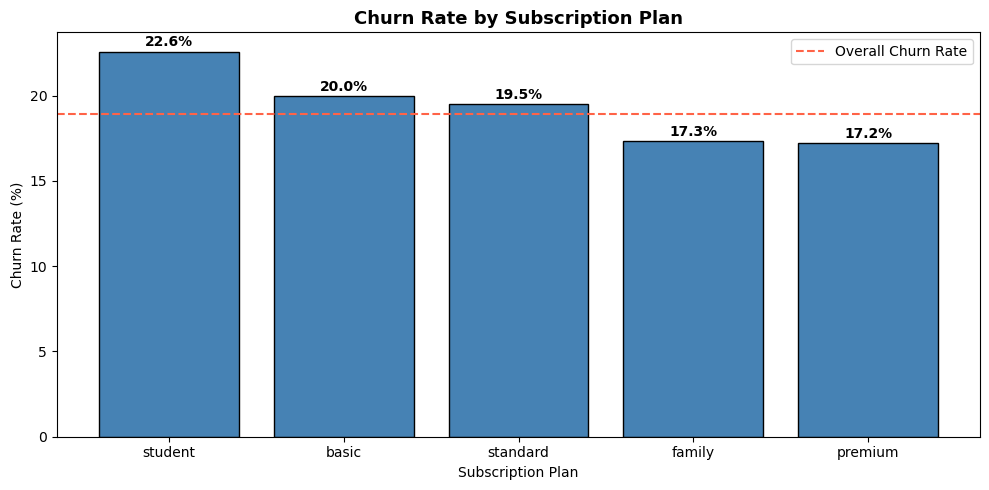

In [22]:
# Visualization 2: Churn Rate by Subscription Plan

churn_by_plan = df.groupby('subscription_plan')['will_churn'].mean() * 100
churn_by_plan = churn_by_plan.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(churn_by_plan.index, churn_by_plan.values,
               color='steelblue', edgecolor='black')
plt.axhline(y=df['will_churn'].mean() * 100, color='tomato',
            linestyle='--', linewidth=1.5, label='Overall Churn Rate')
plt.title('Churn Rate by Subscription Plan', fontsize=13, fontweight='bold')
plt.xlabel('Subscription Plan')
plt.ylabel('Churn Rate (%)')
plt.legend()
for bar, val in zip(bars, churn_by_plan.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{val:.1f}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('viz2_churn_by_plan.png', dpi=150, bbox_inches='tight')
plt.show()

The bar chart compares churn rates across different subscription tiers (e.g., Basic, Standard, Premium). The red dashed line marks the overall average churn rate as a reference. As we can see, the lower-tier plans show higher churn, suggesting that price-sensitive customers are easier to lose and premium features drive retention.

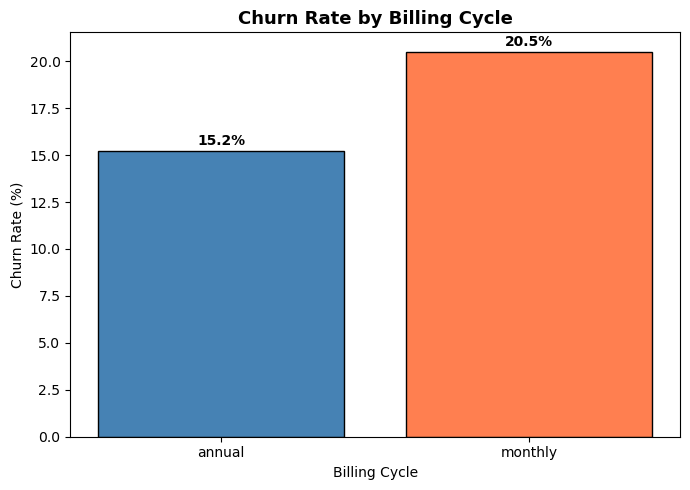

In [23]:
# Visualization 3: Churn Rate by Billing Cycle

churn_by_billing = df.groupby('billing_cycle')['will_churn'].mean() * 100

plt.figure(figsize=(7, 5))
bars = plt.bar(churn_by_billing.index, churn_by_billing.values,
               color=['steelblue', 'coral'], edgecolor='black')
plt.title('Churn Rate by Billing Cycle', fontsize=13, fontweight='bold')
plt.xlabel('Billing Cycle')
plt.ylabel('Churn Rate (%)')
for bar, val in zip(bars, churn_by_billing.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{val:.1f}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('viz3_churn_by_billing.png', dpi=150, bbox_inches='tight')
plt.show()

This chart compares churn between monthly and annual billing. Customers on annual billing are seen to churn less, as they've made a longer financial commitment. The notable difference between the two bars confirms that billing cycle is a meaningful predictor.

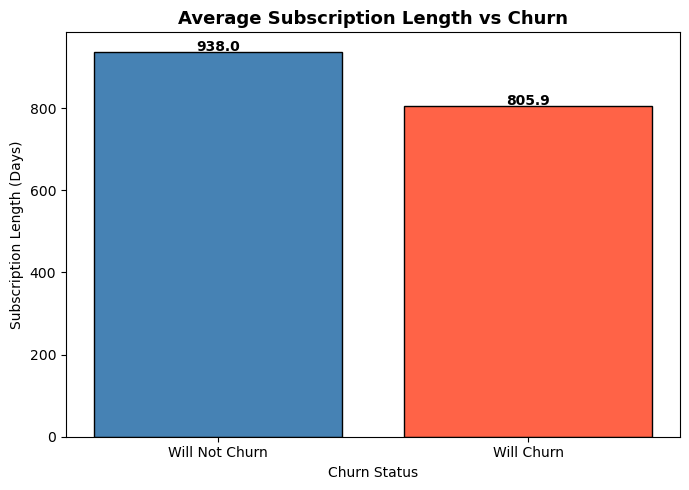

In [24]:
# Visualization 4: Subscription Length vs Churn

churn_avg_sub = df.groupby('will_churn')['subscription_length_days'].mean()

plt.figure(figsize=(7, 5))
plt.bar(['Will Not Churn', 'Will Churn'], churn_avg_sub.values,
        color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Average Subscription Length vs Churn', fontsize=13, fontweight='bold')
plt.xlabel('Churn Status')
plt.ylabel('Subscription Length (Days)')
for i, v in enumerate(churn_avg_sub.values):
    plt.text(i, v + 1, f"{v:.1f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('viz4_subscription_length.png', dpi=150, bbox_inches='tight')
plt.show()

Customers who churned had shorter subscription lengths on average.

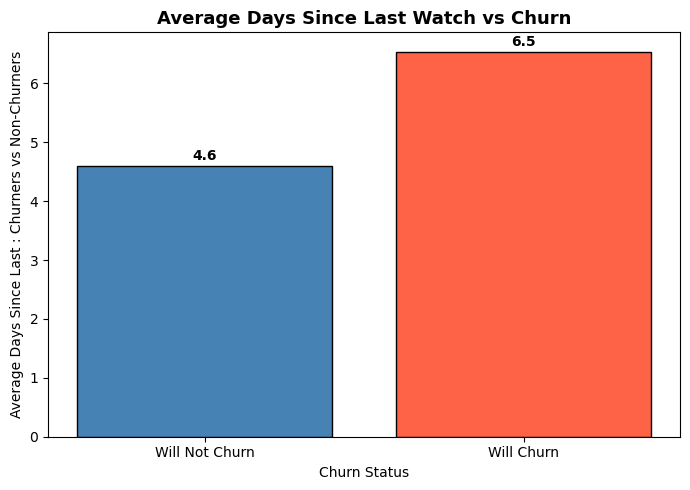

In [27]:
# Visualization 5: Days Since Last Watch vs Churn

churn_avg_days = df.groupby('will_churn')['days_since_last_watch'].mean()

plt.figure(figsize=(7, 5))
plt.bar(['Will Not Churn', 'Will Churn'], churn_avg_days.values,
        color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Average Days Since Last Watch vs Churn', fontsize=13, fontweight='bold')
plt.xlabel('Churn Status')
plt.ylabel('Average Days Since Last : Churners vs Non-Churners')
for i, v in enumerate(churn_avg_days.values):
    plt.text(i, v + 0.1, f"{v:.1f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('viz5_days_since_watch.png', dpi=150, bbox_inches='tight')
plt.show()

Customers who churned had significantly more days since their last watch. This confirms inactivity is a strong churn signal.

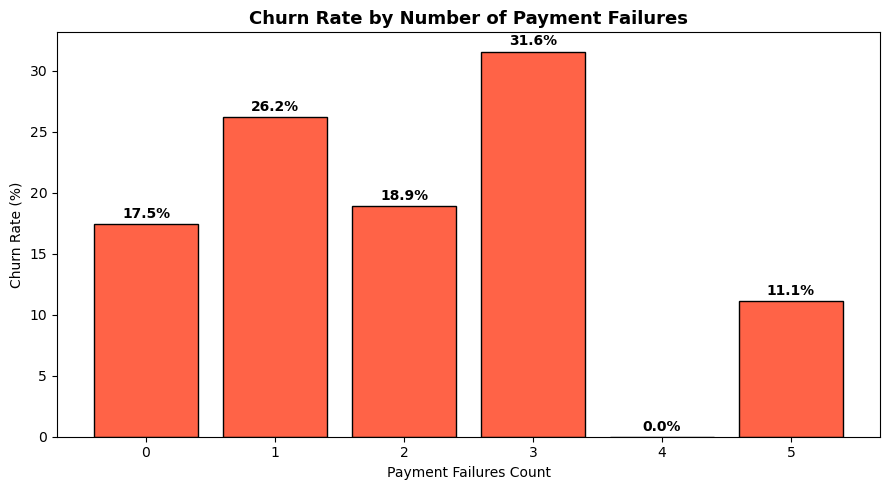

In [28]:
# Visualization 6: Payment Failures vs Churn

payment_churn = df.groupby('payment_failures_count')['will_churn'].mean() * 100
payment_churn = payment_churn[payment_churn.index <= 5]

plt.figure(figsize=(9, 5))
plt.bar(payment_churn.index, payment_churn.values, color='tomato', edgecolor='black')
plt.title('Churn Rate by Number of Payment Failures', fontsize=13, fontweight='bold')
plt.xlabel('Payment Failures Count')
plt.ylabel('Churn Rate (%)')
plt.xticks(payment_churn.index)
for i, v in zip(payment_churn.index, payment_churn.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('viz6_payment_failures_churn.png', dpi=150, bbox_inches='tight')
plt.show()

It is expected that customers with 1 or more payment failures will have high churn rates. The graph supports this expectation, except for payment failure = 5. According to our dataset, customers with 5 payment failures does not have a very high churn rate. This still justifies the payment_risk_score feature, as financial friction is a strong and actionable churn driver.

Note: The churn rate for payment failure = 4 is 0% because our dataset does not have any customers with 4 payment failures.

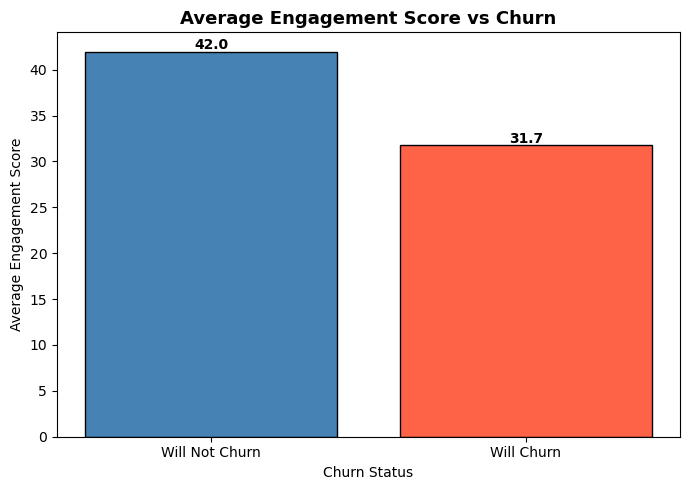

In [29]:
# Visualization 7: Engagement Score vs Churn

churn_avg_engagement = df.groupby('will_churn')['engagement_score'].mean()

plt.figure(figsize=(7, 5))
plt.bar(['Will Not Churn', 'Will Churn'], churn_avg_engagement.values,
        color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Average Engagement Score vs Churn', fontsize=13, fontweight='bold')
plt.xlabel('Churn Status')
plt.ylabel('Average Engagement Score')
for i, v in enumerate(churn_avg_engagement.values):
    plt.text(i, v + 0.3, f"{v:.1f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('viz7_engagement_score.png', dpi=150, bbox_inches='tight')
plt.show()

Churning customers have noticeably lower engagement scores. This confirms our engineered feature carries predictive value.

# Modelling

In [30]:
X = df.drop("will_churn", axis=1)
y = df["will_churn"]

## Train-Test Split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [32]:
#splitting the features into numerical and categorical

numeric_features = X.select_dtypes(include=["int64","float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

## Creating Pipeline

In [33]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")), #handling missing values
    ("scaler", StandardScaler()) #standardization
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")), #handling missing values
    ("encoder", OneHotEncoder(handle_unknown="ignore")) #one-hot encoding
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

## SMOTE for Handling Class Imbalance

In [34]:
smote = SMOTE(random_state=42)

In [35]:
#checking the application of smote

# First, preprocess the training data
X_train_processed = preprocessor.fit_transform(X_train)

# Then apply smote
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_processed, y_train)

print(f"Before SMOTE - Churn: {y_train.sum()}, No Churn: {(y_train == 0).sum()}")
print(f"After SMOTE  - Churn: {y_train_balanced.sum()}, No Churn: {(y_train_balanced == 0).sum()}")

Before SMOTE - Churn: 1511, No Churn: 6489
After SMOTE  - Churn: 6489, No Churn: 6489


Thus we can see, SMOTE has succesfully created a balanced training dataset.

## Using Multiple Models for Comaparison

In [36]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(n_estimators=200),
    "XGBoost": XGBClassifier(eval_metric="logloss")
}

## Cross Validation

In [37]:
scoring_metrics = {
    "roc_auc": "roc_auc",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

for name, model in models.items():

    pipeline = ImbPipeline([
        ("preprocessing", preprocessor),
        ("smote", smote),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring=scoring_metrics
    )

    print("\n", name)
    print("ROC-AUC:", scores["test_roc_auc"].mean())
    print("Precision:", scores["test_precision"].mean())
    print("Recall:", scores["test_recall"].mean())
    print("F1:", scores["test_f1"].mean())



 LogisticRegression
ROC-AUC: 0.7028062974231177
Precision: 0.3494740020952484
Recall: 0.4553537472952593
F1: 0.3952632009776975

 RandomForest
ROC-AUC: 0.738023053843445
Precision: 0.49619121230976637
Recall: 0.0628833081983695
F1: 0.11110688422593189

 XGBoost
ROC-AUC: 0.7262379343493315
Precision: 0.4492685451803099
Recall: 0.20185998732323568
F1: 0.2783930061236356


As we can see -- 
Logistic Regression gives the best Recall and F1 score

Random Forest gives the best ROC-AUC and Precision

XGBoost does not significantly improve the model performance than others.

Since, in churn predictions, it is important for the model to correctly identify as many churn customers as possible, it means **Recall is the value our model should focus to improve**. Hence, in this case, out of all the three models, **Logistic Regression is the best performing model**.

## Hyperparameter Tuning

The ROC-AUC value of our best performing model is 0.702. We will try to improve this by adjusting the model parameters.

In [38]:
param_grid_lr = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"]
}

pipeline_lr = ImbPipeline([
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000))
])

grid_lr = GridSearchCV(
    pipeline_lr,
    param_grid_lr,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print("Best Parameters:", grid_lr.best_params_)
print("Best ROC-AUC:", grid_lr.best_score_)

Best Parameters: {'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best ROC-AUC: 0.7344566842359217


Since the chosen C is the smallest value in the grid, we can try smaller values of C to see if model improves.

In [39]:
param_grid_lr = {
    "model__C": np.logspace(-4, -1, 10),  # 10 values between 0.0001 and 0.1
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"]
}

pipeline_lr = ImbPipeline([
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000))
])

grid_lr = GridSearchCV(
    pipeline_lr,
    param_grid_lr,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print("Best Parameters:", grid_lr.best_params_)
print("Best ROC-AUC:", grid_lr.best_score_)

Best Parameters: {'model__C': np.float64(0.002154434690031882), 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best ROC-AUC: 0.7371186538025012


This time with a further reduced C value, the ROC score has improved to 0.737. So we will use these parameters.

## Fitting the Best Model

In [40]:
best_model = grid_lr.best_estimator_

best_model.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [41]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

## Improving Recall by adjusting threshold

In our Logistic Regression Model, the recall value is around 45%. Let us try to improve that value by adjusting the threshold, which is by default 0.5

In [42]:
from sklearn.metrics import recall_score

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]
precisions = []
recalls = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred))
    recalls.append(recall_score(y_test, y_pred))

# Creating a summary table
threshold_summary = pd.DataFrame({
    "Threshold": thresholds,
    "Precision": precisions,
    "Recall": recalls
})

print(threshold_summary)

   Threshold  Precision    Recall
0        0.1   0.189759  1.000000
1        0.2   0.199244  0.976190
2        0.3   0.233903  0.941799
3        0.4   0.270514  0.793651
4        0.5   0.327935  0.642857


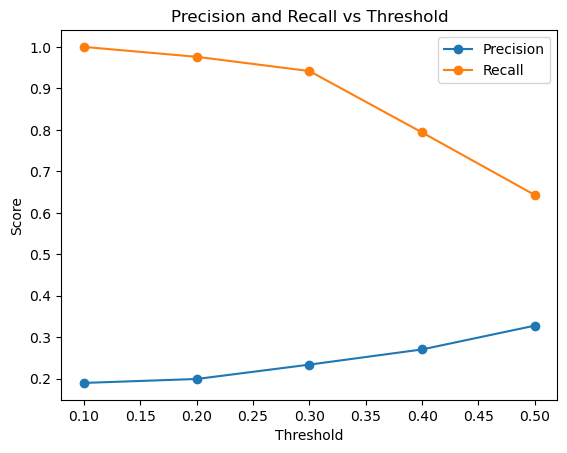

In [43]:
plt.plot(thresholds, precisions, marker='o', label='Precision')
plt.plot(thresholds, recalls, marker='o', label='Recall')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs Threshold')
plt.legend()
plt.show()

From the above result, we see that the recall increases significantly with lower thresholds. While thresholds 0.1 and 0.2 give very high recalls, they lower the precision significantly, thus increasing false positives, which would not be practical for the business. At 0.4 and 0.5 the recall has a significant drop. Hence, it would be best to **choose the threshold to be 0.3**, which will result in the model catching significant amount of churn customers, while keeping precision manageable.

# Classification Report (with new Threshold)

In [44]:
threshold = 0.30
y_pred_adjusted = (y_prob >= threshold).astype(int)

print(classification_report(y_test, y_pred_adjusted))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.95      0.28      0.43      1622
           1       0.23      0.94      0.37       378

    accuracy                           0.41      2000
   macro avg       0.59      0.61      0.40      2000
weighted avg       0.82      0.41      0.42      2000

ROC-AUC: 0.7250732324715062


The threshold of 0.3 gives quite a well performing model. The model captures 94% of the churn customers, while having manageable false positives. The precision-recall balance (f1 score) and ROC-AUC have very little change, indicating the model discrimination is still strong.

Accuracy is 41%. But, this being an imbalanced dataset, accuracy does not reflect the true performance of the model.

# Confusion Matrix

In [46]:
cm = confusion_matrix(y_test, y_pred_adjusted)

cm_df = pd.DataFrame(
    cm,
    index=["Actual No Churn", "Actual Churn"],
    columns=["Predicted No Churn", "Predicted Churn"]
)

print(cm_df)

                 Predicted No Churn  Predicted Churn
Actual No Churn                 456             1166
Actual Churn                     22              356


The Confusion Matrix shows quite a low number of False Negatives, which is expected, since we were aiming for high recall. However, as we can see, the number of false positives is pretty high as a result of that. Hence, to reduce wastage of business resources, we will divide the customers in different risk segments, so that the business can target high risk customers as a priority and efficiently allocate its resources.

# Customer Risk Segmentation

To handle the low precision of our model, we will create a risk segmentation, allowing the business to prioritize High Risk customers efficiently

In [47]:
# Predicting probabilities for all customers
df['churn_prob'] = best_model.predict_proba(X)[:,1]

# Dividing customers into risk categories
df['churn_risk_segment'] = pd.cut(
    df['churn_prob'],
    bins=[0, 0.3, 0.6, 1],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

risk_summary = df.groupby('churn_risk_segment', observed = False)['churn_prob'].agg(['count','mean'])
risk_summary["percentage"] = (risk_summary["count"] / len(df)) * 100
risk_summary

,count,mean,percentage
churn_risk_segment,,,
Low Risk,2458,0.219649,24.58
Medium Risk,5383,0.439559,53.83
High Risk,2159,0.721968,21.59


This shows around 22% of the customers are at high risk of churning (average 72% risk). These customers should be prioritized for proactive retention interventions such as targeted offers and personalized recommendations. The business can focus on these 22% customers first, instead of the entire user base, thus efficiently handling the marketing cost.

# ROC Curve

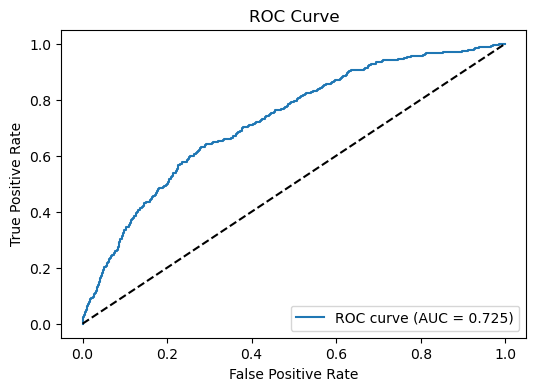

In [48]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1],[0,1],'k--') 
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

# Feature importance

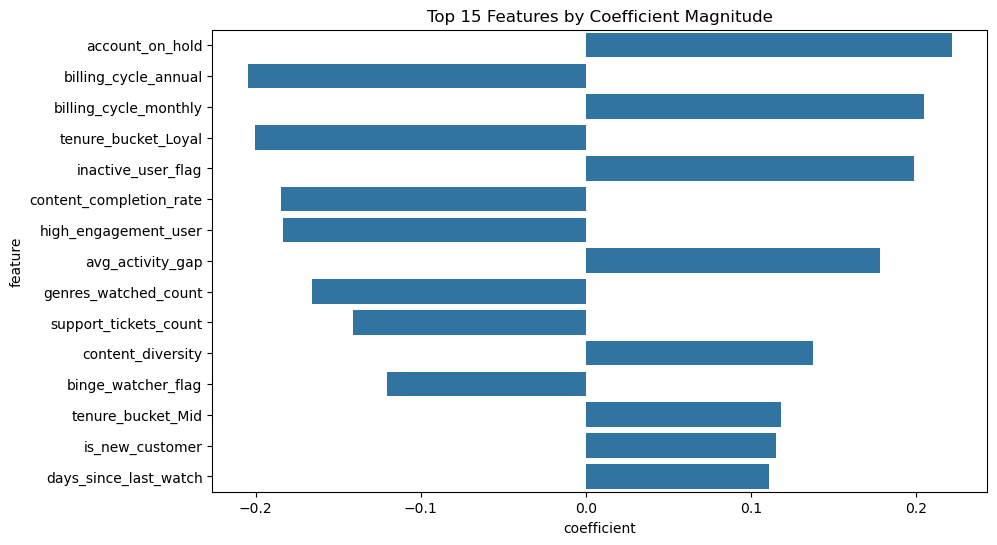

,feature,coefficient
21,account_on_hold,0.221780
42,billing_cycle_annual,-0.204887
43,billing_cycle_monthly,0.204569
6261,tenure_bucket_Loyal,-0.200232
31,inactive_user_flag,0.198966
7,content_completion_rate,-0.184560
35,high_engagement_user,-0.183106
36,avg_activity_gap,0.178086
10,genres_watched_count,-0.165849
19,support_tickets_count,-0.141166


In [49]:
# For numeric features only
feature_names = numeric_features.tolist() + list(best_model.named_steps['preprocessing'].transformers_[1][1].get_feature_names_out())
coefficients = best_model.named_steps['model'].coef_[0]

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
}).sort_values(by='coefficient', key=abs, ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='coefficient', y='feature', data=feature_importance.head(15))
plt.title("Top 15 Features by Coefficient Magnitude")
plt.show()

feature_importance.head(15)

In the above analysis, the **positive coefficients indicate more churn probability**, while the negative coefficients mean customers are less likely to churn. 

As we can see from the top 15 feature importance chart, new customers or customers with suspended account or longer inactivity are more likely to churn. 

Whereas customers belonging to the Loyal tenure bucket, those who binge watch, watch multiple genres or complete watching contents are less likely to churn. 

Also, we can see that customers with annual billing cycle are less likely to churn than those with monthly billing cycle.

# Saving Model for Future Use

In [50]:
import joblib

joblib.dump(best_model, 'logreg_churn_model_threshold0.3.pkl')
print("Model saved as 'logreg_churn_model_threshold0.3.pkl'")

Model saved as 'logreg_churn_model_threshold0.3.pkl'


In [51]:
##To load model in the future

#import joblib
#model = joblib.load("logreg_churn_model_threshold0.4.pkl")